<a href="https://colab.research.google.com/github/yuhui-0611/ESAA/blob/main/ESAA_OB_project_for_paper_total.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **A Predictive Analysis of Real Estate Investment Decisions Using XGBoost**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing

< 전처리 순서 >

1. 각 연도 df 읽기
2. 각 연도 df에서 논문 기초통계량 17개 변수만 추출
3. 컬럼명을 분석용 공통 이름으로 변경
4. 연도 변수 추가
5. 2019~2025 데이터 병합
6. 코드형 변수 값 분포 확인
7. 논문 기준 더미 변수 생성
8. 불필요한 raw 변수 제거
9. 전체 데이터 결측치 확인
10. 전체 데이터 자료형 확인 및 숫자형 변환
11. 최종 분석용 데이터 완성

## **1. 각 연도 df 읽기**
   - 2019~2025년 csv 읽기
   - data_dict에 저장

In [ ]:
base_path = '/content/drive/MyDrive/ESAA_OB_pj/논문/가구데이터'

# MDIS 자료는 보통 utf-8이 아니라 cp949 또는 euc-kr 인코딩인 경우가 많음
def read_csv_korean(file_path):
    try:
        df = pd.read_csv(file_path, encoding='cp949')
    except UnicodeDecodeError:
        df = pd.read_csv(file_path, encoding='euc-kr')

    return df

In [ ]:
data_dict = {}

for year in range(2019, 2026):
    file_path = f'{base_path}/{year}.csv'
    df = read_csv_korean(file_path)
    data_dict[year] = df
    print(f'{year}년 데이터 읽기 완료 | shape: {df.shape}')

2019년 데이터 읽기 완료 | shape: (18406, 159)
2020년 데이터 읽기 완료 | shape: (18064, 159)
2021년 데이터 읽기 완료 | shape: (18187, 160)
2022년 데이터 읽기 완료 | shape: (17954, 160)
2023년 데이터 읽기 완료 | shape: (18094, 160)
2024년 데이터 읽기 완료 | shape: (18314, 162)
2025년 데이터 읽기 완료 | shape: (18664, 160)


In [ ]:
# 2019~2025년 데이터 컬럼명 확인

for year in range(2019, 2026):
    file_path = f'{base_path}/{year}.csv'

    try:
        df = pd.read_csv(file_path, encoding='cp949')
    except UnicodeDecodeError:
        df = pd.read_csv(file_path, encoding='euc-kr')

    print('=' * 80)
    print(f'{year}년 데이터')
    print(f'데이터 크기: {df.shape}')
    print(f'컬럼 개수: {len(df.columns)}')
    print()
    print(df.columns.tolist())
    print()

2019년 데이터
데이터 크기: (18406, 159)
컬럼 개수: 159

['조사연도', 'MD제공용_가구고유번호', '가중값', '수도권여부', '가구주_성별코드', '가구원수', '노인가구코드', '조손가구코드', '한부모가구코드', '다문화가구코드', '보완_등록장애인유무_가구구분코드', '가구주_교육정도_학력코드', '가구주_교육정도_수학구분코드', '가구주_교육정도_통합코드', '가구주_동거여부', '가구주_산업대분류코드', '가구주_직업대분류코드', '가구주_만연령', '가구주연령_10세단위코드', '가구주_종사상지위코드', '보도용_가구주_종사상지위코드', '가구주_혼인상태코드', '입주형태코드', '입주형태통합코드', '전용면적규모코드', '주택종류통합코드', '부채보유여부', '보완_소득5분위코드', '보완_소득10분위코드', '보도용_보완_소득계층구간코드', '자산총액5분위코드', '자산총액10분위코드', '순자산5분위코드', '순자산10분위코드', '자산', '자산_금융자산', '자산_금융자산_저축금액', '자산_금융자산_저축_적립예치식저축금액', '자산_금융자산_저축_적립예치식저축_수시적립예치식저축금액', '자산_금융자산_저축_적립예치식저축_저축성보장성보험금액', '자산_금융자산_저축_적립예치식저축_주식채권펀드금액', '자산_금융자산_저축_기타저축금액', '자산_금융자산_현거주지전월세보증금', '자산_실물자산', '자산_실물자산_부동산금액', '자산_실물자산_부동산_거주주택금액', '자산_실물자산_부동산_거주주택이외부동산금액', '자산_실물자산_부동산_계약금중도금납입금액', '자산_실물자산_기타실물자산', '자산_실물자산_기타실물자산_자동차금액', '자산_실물자산_기타실물자산_기타금액', '자산_실물자산_기타실물자산_기타_자동차이외기타실물자산', '자산_실물자산_기타실물자산_기타_권리금', '부채', '부채_금융부채', '부채_금융부채_담보대출금액', '부채_금융부채_담보대출_대출용도_거주주택구입금액', '부채_금융부채_담보대출_대출용

## **2. 각 연도 df에서 논문 기초통계량 17개 변수만 추출**
   - col_map 기준으로 후보 컬럼 중 존재하는 컬럼 선택
   - 코드북이랑 대응되는 컬럼 추출

In [ ]:
col_map = {
    'investment_decision': ['여유자금부동산투자여부'],
    'sma': ['수도권여부'],
    'head_gender': ['가구주_성별코드'],
    'college_or_higher_raw': ['가구주_교육정도_통합코드'],
    'own_house_raw': ['입주형태코드', '입주형태통합코드'],
    'income_decile': ['보완_소득10분위코드', '소득10분위코드(보완)(2017년~)'],
    'household_members': ['가구원수'],
    'head_age': ['가구주_만연령'],
    'financial_assets': ['자산_금융자산'],
    'real_assets': ['자산_실물자산'],
    'secured_loan': ['부채_금융부채_담보대출금액'],
    'unsecured_loan': ['부채_금융부채_신용대출금액'],
    'principal_interest_repayment': ['원리금상환금액'],
    'net_worth': ['순자산'],
    'current_income': ['보완_경상소득', '경상소득(보완)'],
    'expenditure': ['지출_소비지출비'],
    'repayment_to_income_ratio': ['원리금상환_생계부담_소득대비상환액비중']
}

In [ ]:
# col_map에 들어간 후보 컬럼들이 각 연도에 존재하는지 확인

exist_check = []

for year, df in data_dict.items():
    for analysis_var, candidate_cols in col_map.items():

        matched_col = None

        for col in candidate_cols:
            if col in df.columns:
                matched_col = col
                break

        exist_check.append({
            'year': year,
            'analysis_var': analysis_var,
            'matched_column': matched_col,
            'exists': matched_col is not None
        })

exist_df = pd.DataFrame(exist_check)

exist_df

,year,analysis_var,matched_column,exists
0,2019,investment_decision,여유자금부동산투자여부,True
1,2019,sma,수도권여부,True
2,2019,head_gender,가구주_성별코드,True
3,2019,college_or_higher_raw,가구주_교육정도_통합코드,True
4,2019,own_house_raw,입주형태코드,True
...,...,...,...,...
114,2025,principal_interest_repayment,원리금상환금액,True
115,2025,net_worth,순자산,True
116,2025,current_income,경상소득(보완),True
117,2025,expenditure,지출_소비지출비,True


In [ ]:
# 존재하지 않는 변수 확인

missing_df = exist_df[exist_df['exists'] == False]

missing_df

,year,analysis_var,matched_column,exists


- 존재하지 않는 변수 없음 -> 대응되는 컬럼 추출 완료
> col_map에 넣은 후보 컬럼들이 2019~2025년 모든 데이터에서 하나씩 정상적으로 매칭됐다는 뜻

## **3. 컬럼명을 분석용 공통 이름으로 변경**
   - 예: 여유자금부동산투자여부 → investment_decision
   - 예: 보완_경상소득 / 경상소득(보완) → current_income

## **4. 연도 변수 추가**
   - year = 2019, 2020, ..., 2025

## **5. 2019~2025 데이터 병합**
   - df_all 생성

In [ ]:
# 여러 후보 컬럼 중 실제 존재하는 컬럼을 찾는 함수

def get_existing_col(df, candidates):
    for col in candidates:
        if col in df.columns:
            return col
    return None

In [ ]:
# 각 연도 df에서 17개 변수만 추출하고 공통 컬럼명으로 변경

processed_dfs = []

for year, df in data_dict.items():
    temp = pd.DataFrame()

    for analysis_var, candidate_cols in col_map.items():
        matched_col = get_existing_col(df, candidate_cols)
        temp[analysis_var] = df[matched_col]

    temp['year'] = year

    processed_dfs.append(temp)

df_all = pd.concat(processed_dfs, ignore_index=True)

print(df_all.shape)
df_all.head()

(127683, 18)


,investment_decision,sma,head_gender,college_or_higher_raw,own_house_raw,income_decile,household_members,head_age,financial_assets,real_assets,secured_loan,unsecured_loan,principal_interest_repayment,net_worth,current_income,expenditure,repayment_to_income_ratio,year
0,1,G1,1,G4,2,D04,6,56,12460,32000,4000,7000,1285,25620,3360,4044,NaN,2019
1,2,G1,2,G2,2,D05,2,64,38310,48175,0,0,0,79485,4090,3125,NaN,2019
2,2,G1,1,G3,1,D01,2,84,200,20150,0,0,0,20350,774,1350,NaN,2019
3,2,G1,1,G3,1,D08,4,57,2268,44230,10000,0,1430,36198,7411,3070,NaN,2019
4,1,G1,1,G4,1,D09,5,56,25674,132500,23000,900,1085,134274,10219,4940,NaN,2019


- 3~5 단계 한 번에 시행

## **6. 코드형 변수 값 분포 확인**
   - investment_decision, sma, head_gender, college_or_higher_raw, own_house_raw, income_decile 확인

In [ ]:
# 코드형 변수 값 분포 확인

code_cols = [
    'investment_decision',
    'sma',
    'head_gender',
    'college_or_higher_raw',
    'own_house_raw',
    'income_decile'
]

for col in code_cols:
    print('=' * 80)
    print(col)
    print(df_all[col].value_counts(dropna=False).sort_index())

investment_decision
investment_decision
1    61246
2    66437
Name: count, dtype: int64
sma
sma
G1    41431
G2    86252
Name: count, dtype: int64
head_gender
head_gender
1    92407
2    35276
Name: count, dtype: int64
college_or_higher_raw
college_or_higher_raw
G1    24374
G2    13876
G3    41312
G4    48121
Name: count, dtype: int64
own_house_raw
own_house_raw
1    78890
2    14823
3    23489
4     1802
5     8679
Name: count, dtype: int64
income_decile
income_decile
D01    16620
D02    15516
D03    13898
D04    12974
D05    12428
D06    11914
D07    11403
D08    11069
D09    10902
D10    10959
Name: count, dtype: int64


## **7. 논문 기준 더미 변수 생성**
   - 투자=1
   - 수도권=1
   - 남자=1
   - 대학졸업 이상=1
   - 자가=1
   - 소득10분위는 숫자형 1~10으로 변환

> 코드북이랑 비교한 결과

investment_decision: 1 = 투자, 2 = 비투자

sma: G1 = 수도권, G2 = 비수도권

head_gender: 1 = 남자, 2 = 여자

college_or_higher_raw: G4 = 대학졸업 이상

own_house_raw: 1 = 자가

income_decile: D01 ~ D10 = 소득 1 ~ 10분위

In [ ]:
df_all['investment_decision'] = (df_all['investment_decision'] == 1).astype(int)

df_all['sma'] = (df_all['sma'] == 'G1').astype(int)

df_all['head_gender'] = (df_all['head_gender'] == 1).astype(int)

df_all['college_or_higher'] = (df_all['college_or_higher_raw'] == 'G4').astype(int)

df_all['own_house'] = (df_all['own_house_raw'] == 1).astype(int)

df_all['income_decile'] = df_all['income_decile'].str.replace('D', '', regex=False).astype(int)

In [ ]:
# 더미 변수 변환 결과 확인

check_cols = [
    'investment_decision',
    'sma',
    'head_gender',
    'college_or_higher',
    'own_house',
    'income_decile'
]

for col in check_cols:
    print('=' * 80)
    print(col)
    print(df_all[col].value_counts(dropna=False).sort_index())

investment_decision
investment_decision
0    66437
1    61246
Name: count, dtype: int64
sma
sma
0    86252
1    41431
Name: count, dtype: int64
head_gender
head_gender
0    35276
1    92407
Name: count, dtype: int64
college_or_higher
college_or_higher
0    79562
1    48121
Name: count, dtype: int64
own_house
own_house
0    48793
1    78890
Name: count, dtype: int64
income_decile
income_decile
1     16620
2     15516
3     13898
4     12974
5     12428
6     11914
7     11403
8     11069
9     10902
10    10959
Name: count, dtype: int64


- 변환 완료

## **8. 불필요한 raw 변수 제거**
   - college_or_higher_raw
   - own_house_raw 등

In [ ]:
df_all = df_all.drop(columns=[
    'college_or_higher_raw',
    'own_house_raw'
])

- investment_decision, sma, head_gender, income_decile은 기존 컬럼을 그대로 변환했기 때문에 제거하면 안됨

## **9. 전체 데이터 결측치 확인**
   - 변수별 결측 개수 확인
   - 결측 처리 방식 결정

In [ ]:
missing_summary = df_all.isna().sum().sort_values(ascending=False)
missing_summary

,0
repayment_to_income_ratio,105707
investment_decision,0
sma,0
head_gender,0
household_members,0
income_decile,0
financial_assets,0
real_assets,0
secured_loan,0
head_age,0


## **10. 전체 데이터 자료형 확인 및 숫자형 변환**
   - 금액 변수, 소득 변수, 지출 변수 numeric 처리



In [ ]:
df_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 127683 entries, 0 to 127682
Data columns (total 18 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   investment_decision           127683 non-null  int64  
 1   sma                           127683 non-null  int64  
 2   head_gender                   127683 non-null  int64  
 3   income_decile                 127683 non-null  int64  
 4   household_members             127683 non-null  int64  
 5   head_age                      127683 non-null  int64  
 6   financial_assets              127683 non-null  int64  
 7   real_assets                   127683 non-null  int64  
 8   secured_loan                  127683 non-null  int64  
 9   unsecured_loan                127683 non-null  int64  
 10  principal_interest_repayment  127683 non-null  int64  
 11  net_worth                     127683 non-null  int64  
 12  current_income                127683 non-nul

- repayment_to_income_ratio
  - 정수형 컬럼에 NaN이 섞이면 보통 float64로 처리

repayment_to_income_ratio: 원리금 상환액이 있는 가구에만 의미 있는 변수

-> 결측치 대부분은 부채가 없어서 원리금 상환이 없고 비율 계산 불가이므로 결측이 "상환액 없음"이라는 정보를 내포

-> 결측 자체를 피처로 이용

- repayment_to_income_ratio : 결측 -> 0으로 대체
- has_repayment : 원리금 상황 가구 여부 더미


In [ ]:
# 결측 여부 더미 변수 생성 (1 = 원리금 상환 있음, 0 = 없음/결측)
df_all['has_repayment'] = df_all['repayment_to_income_ratio'].notna().astype(int)

# 결측치 0으로 대체 (float64 유지)
df_all['repayment_to_income_ratio'] = df_all['repayment_to_income_ratio'].fillna(0)

# 확인
print(df_all[['repayment_to_income_ratio', 'has_repayment']].info())
print()
print(df_all['has_repayment'].value_counts())
print()
print(df_all['repayment_to_income_ratio'].describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 127683 entries, 0 to 127682
Data columns (total 2 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   repayment_to_income_ratio  127683 non-null  float64
 1   has_repayment              127683 non-null  int64  
dtypes: float64(1), int64(1)
memory usage: 1.9 MB
None

has_repayment
0    105707
1     21976
Name: count, dtype: int64

count    127683.000000
mean          3.584675
std           8.959213
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          80.000000
Name: repayment_to_income_ratio, dtype: float64


In [ ]:
df_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 127683 entries, 0 to 127682
Data columns (total 19 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   investment_decision           127683 non-null  int64  
 1   sma                           127683 non-null  int64  
 2   head_gender                   127683 non-null  int64  
 3   income_decile                 127683 non-null  int64  
 4   household_members             127683 non-null  int64  
 5   head_age                      127683 non-null  int64  
 6   financial_assets              127683 non-null  int64  
 7   real_assets                   127683 non-null  int64  
 8   secured_loan                  127683 non-null  int64  
 9   unsecured_loan                127683 non-null  int64  
 10  principal_interest_repayment  127683 non-null  int64  
 11  net_worth                     127683 non-null  int64  
 12  current_income                127683 non-nul

## **10-2 추가 전처리 확인**

클래스 불균형 확인

XGBoost는 이상치에 덜 민감하므로 굳이 이상치를 없애지 않아도 될 것 같음
- Winsorizing 방식을 이용해 이상치 1~5%의 변수를 전처리하는 방식을 이용해 봤지만 상한과 하한이 잘못 잡히는 문제가 있어서 굳이 진행하지 않아도 될 듯함

다중공선성 확인





In [ ]:
# 클래스 불균형 확인
print(y.value_counts())
print()
print(y.value_counts(normalize=True) * 100)

investment_decision
0    66437
1    61246
Name: count, dtype: int64

investment_decision
0    52.032769
1    47.967231
Name: proportion, dtype: float64


In [ ]:
# 연속형 금액 변수 이상치 현황 확인
continuous_cols = [
    'financial_assets', 'real_assets', 'net_worth',
    'current_income', 'expenditure',
    'secured_loan', 'unsecured_loan',
    'principal_interest_repayment', 'repayment_to_income_ratio',
    'household_members', 'head_age'
]

for col in continuous_cols:
    Q1 = df_all[col].quantile(0.25)
    Q3 = df_all[col].quantile(0.75)
    IQR = Q3 - Q1
    outlier_count = ((df_all[col] < Q1 - 1.5*IQR) | (df_all[col] > Q3 + 1.5*IQR)).sum()
    outlier_pct = outlier_count / len(df_all) * 100
    print(f"{col:35s} | 이상치: {outlier_count:6d}개 ({outlier_pct:.2f}%)")

financial_assets                    | 이상치:  11067개 (8.67%)
real_assets                         | 이상치:   9449개 (7.40%)
net_worth                           | 이상치:   9831개 (7.70%)
current_income                      | 이상치:   5718개 (4.48%)
expenditure                         | 이상치:   4203개 (3.29%)
secured_loan                        | 이상치:  20400개 (15.98%)
unsecured_loan                      | 이상치:  24633개 (19.29%)
principal_interest_repayment        | 이상치:  13959개 (10.93%)
repayment_to_income_ratio           | 이상치:  21976개 (17.21%)
household_members                   | 이상치:    171개 (0.13%)
head_age                            | 이상치:      2개 (0.00%)


/tmp/ipykernel_3597/3065461277.py:27: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3597/3065461277.py:27: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3597/3065461277.py:27: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3597/3065461277.py:27: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3597/3065461277.py:27: UserWarning: Glyph 44288 (\N{HANGUL SYLLABLE GWAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3597/3065461277.py:27: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3597/3065461277.py:27: UserWarning: Glyph 55176 (\N{HANGUL SYLLABLE HI}) missing from font(s) DejaVu Sans.
  plt.tight

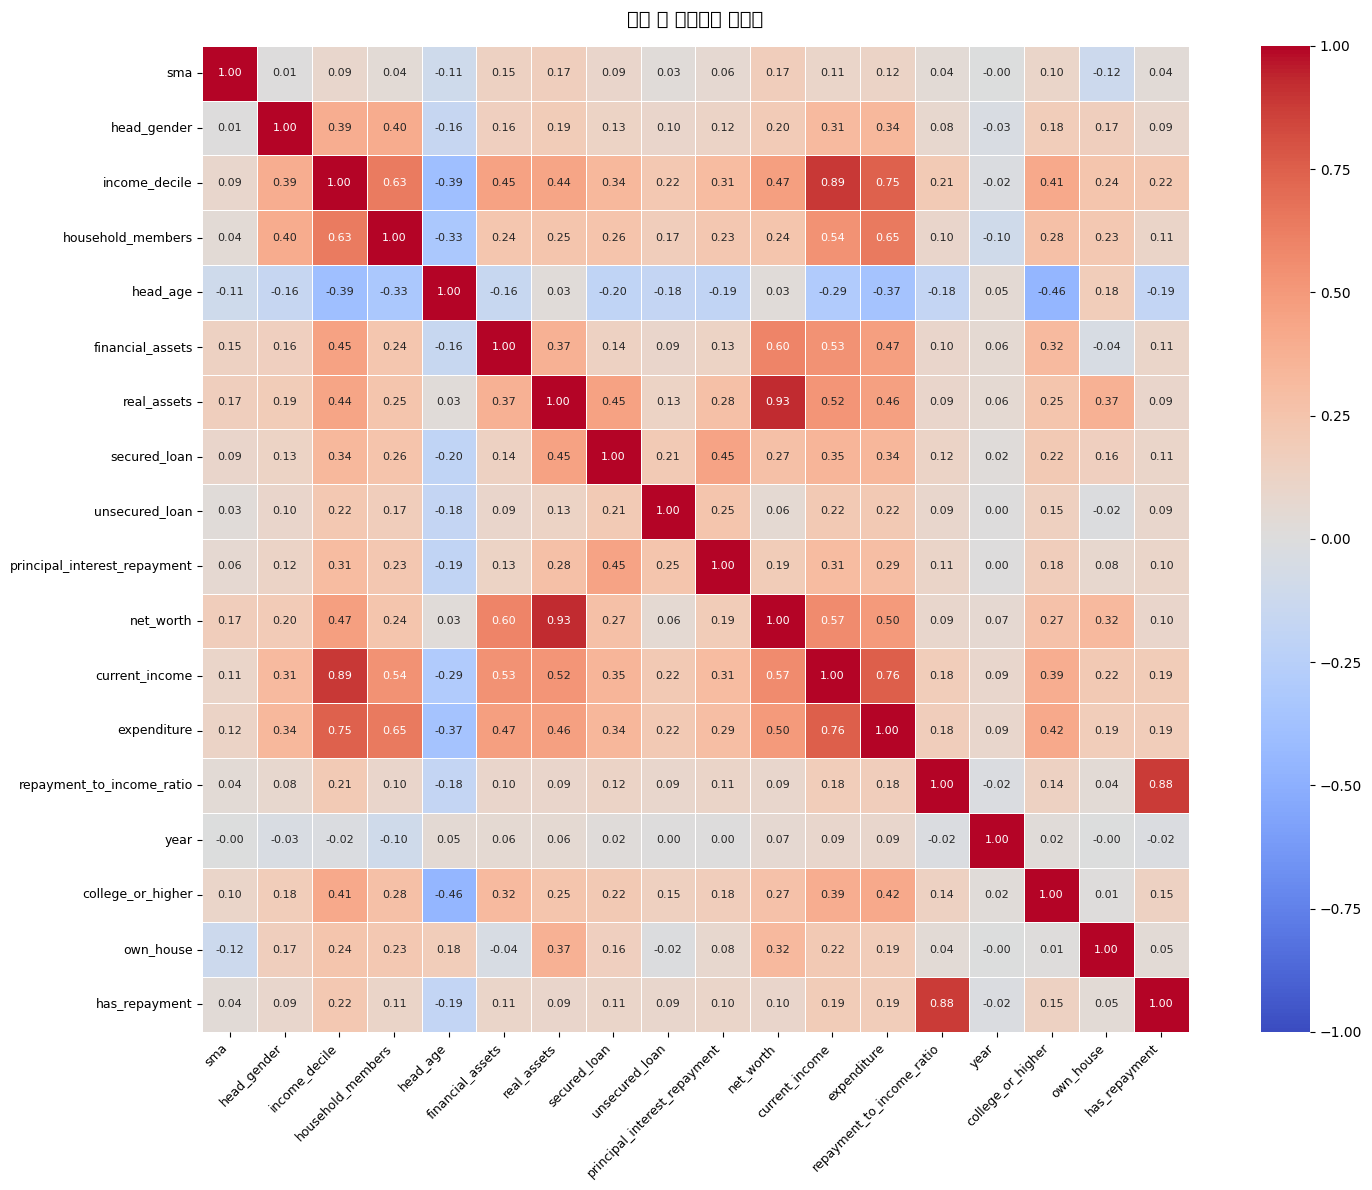


|상관계수| >= 0.7 변수 쌍
income_decile                       & current_income                      | r = 0.887
income_decile                       & expenditure                         | r = 0.749
real_assets                         & net_worth                           | r = 0.928
current_income                      & expenditure                         | r = 0.755
repayment_to_income_ratio           & has_repayment                       | r = 0.881


In [ ]:
# 다중공선성 확인

import matplotlib.pyplot as plt
import seaborn as sns

# 최종 X 변수 기준으로 상관행렬 계산
X_winsor = df_all_winsor.drop(columns=['investment_decision'])

corr_matrix = X_winsor.corr()

# 히트맵 시각화
plt.figure(figsize=(16, 12))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    annot_kws={'size': 8}
)
plt.title('변수 간 상관관계 히트맵', fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

# 높은 상관관계 쌍 출력 (|r| >= 0.7)
print("\n|상관계수| >= 0.7 변수 쌍")
print('=' * 60)
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) >= 0.7:
            print(f"{corr_matrix.columns[i]:35s} & {corr_matrix.columns[j]:35s} | r = {r:.3f}")

**높은 상관관계 쌍 분석**

1. real_assets & net_worth (r = 0.928) ← 가장 심각
- net_worth = 자산 - 부채 이므로 real_assets가 클수록 net_worth도 커지는 구조적 관계
- net_worth 제거 권장 → real_assets, financial_assets, 대출 변수들로 이미 순자산 정보가 분해되어 있음

2. repayment_to_income_ratio & has_repayment (r = 0.881)
- has_repayment가 1일 때만 repayment_to_income_ratio가 0이 아닌 구조적 관계
- has_repayment 제거 권장 → repayment_to_income_ratio 자체가 0/비0으로 이미 상환 여부를 내포

3. income_decile & current_income (r = 0.887)
- 소득분위는 소득액으로 결정되므로 당연한 관계
- income_decile 제거 권장 → current_income이 연속형으로 더 많은 정보 보유

4. income_decile & expenditure (r = 0.749)
- 위와 동일 원인 (income_decile 제거로 자동 해소)

5. current_income & expenditure (r = 0.755)
- 소득이 높을수록 지출도 높은 자연스러운 관계
- 두 변수 모두 독립적 의미가 있으므로 유지 권장

In [ ]:
df_all_winsor = df_all_winsor.drop(columns=[
    'net_worth',        # real_assets와 중복
    'has_repayment',    # repayment_to_income_ratio에 내포
    'income_decile'     # current_income과 중복
])

print(f"최종 컬럼 수: {df_all_winsor.shape[1]}")
print(df_all_winsor.columns.tolist())

최종 컬럼 수: 16
['investment_decision', 'sma', 'head_gender', 'household_members', 'head_age', 'financial_assets', 'real_assets', 'secured_loan', 'unsecured_loan', 'principal_interest_repayment', 'current_income', 'expenditure', 'repayment_to_income_ratio', 'year', 'college_or_higher', 'own_house']


In [ ]:
df_all=df_all_winsor

## **11. 최종 분석용 데이터 완성**
   - y = investment_decision
   - X = 나머지 설명변수

In [ ]:
X = df_all.drop(columns=['investment_decision'])
y = df_all['investment_decision']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\ny 분포:\n{y.value_counts()}")
print(f"\nX 컬럼 목록:\n{X.columns.tolist()}")

X shape: (127683, 15)
y shape: (127683,)

y 분포:
investment_decision
0    66437
1    61246
Name: count, dtype: int64

X 컬럼 목록:
['sma', 'head_gender', 'household_members', 'head_age', 'financial_assets', 'real_assets', 'secured_loan', 'unsecured_loan', 'principal_interest_repayment', 'current_income', 'expenditure', 'repayment_to_income_ratio', 'year', 'college_or_higher', 'own_house']


# 모델링_XGboost

### 필요한 라이브러리

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix, classification_report)
from xgboost import XGBClassifier, plot_importance

### 데이터 로드 및 데이터 분할

In [ ]:
# 1. 데이터 로드
df = pd.read_csv('final_analyzed_data.csv')

# 2. 특성(X)과 타겟(y) 분리
# 종속변수: investment_decision (부동산 투자 여부)
X = df.drop('investment_decision', axis=1)
y = df['investment_decision']

# 3. Train / Test 데이터 분할 (80:20 비율, 클래스 비율 유지)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"학습용 데이터: {X_train.shape}, 테스트용 데이터: {X_test.shape}")

학습용 데이터: (102146, 15), 테스트용 데이터: (25537, 15)


### XGBoost 모델 학습

In [ ]:
# 4. XGBoost 모델 초기화 및 학습
# (분류 문제이므로 binary:logistic 목적 함수 사용)
xgb_model = XGBClassifier(
    n_estimators=200,          # 트리의 개수
    learning_rate=0.05,        # 학습률
    max_depth=6,               # 트리의 최대 깊이
    subsample=0.8,             # 각 트리마다 사용할 데이터 비율 (과적합 방지)
    colsample_bytree=0.8,      # 각 트리마다 사용할 특성 비율 (과적합 방지)
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

# 5. 모델 예측 및 확률값 계산
y_pred = xgb_model.predict(X_test)
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1] # ROC-AUC 계산을 위한 확률값

c:\Users\jk102\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [01:42:25] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


### 모델 성능 평가

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("\n[ XGBoost 모델 성능 지표 ]")
print(f"Accuracy (정확도) : {accuracy:.4f}")
print(f"Precision(정밀도) : {precision:.4f}")
print(f"Recall   (재현율) : {recall:.4f}")
print(f"F1-Score (F1점수) : {f1:.4f}")
print(f"ROC-AUC          : {roc_auc:.4f}")

print("\n[ Classification Report ]")
print(classification_report(y_test, y_pred))


[ XGBoost 모델 성능 지표 ]
Accuracy (정확도) : 0.6830
Precision(정밀도) : 0.6577
Recall   (재현율) : 0.7074
F1-Score (F1점수) : 0.6816
ROC-AUC          : 0.7443

[ Classification Report ]
              precision    recall  f1-score   support

           0       0.71      0.66      0.68     13288
           1       0.66      0.71      0.68     12249

    accuracy                           0.68     25537
   macro avg       0.68      0.68      0.68     25537
weighted avg       0.68      0.68      0.68     25537



### Confusion Matrix

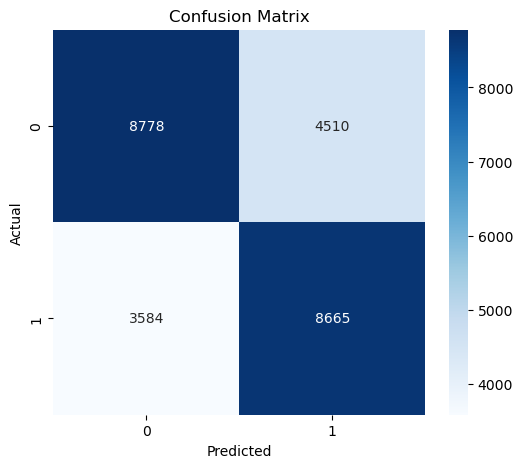

In [ ]:
# 7. Confusion Matrix 시각화
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

1. 모델 성능 평가 (Model Performance)
- 전반적 성능: 정확도(Accuracy) 68.3%, ROC-AUC 0.7443

- 해석: 보통 인간의 심리나 의향(부동산 투자 여부)을 예측하는 사회과학/경제 데이터 분석에서는 예측 변수가 통제하기 어렵기 때문에 AUC 0.7 이상의 수치면 상당히 유의미한 예측력을 가진 모델로 평가받는다.

- 안정성: 0과 1 클래스에 대한 정밀도(Precision)와 재현율(Recall)이 0.65~0.71 사이로 고르게 분포하고 있어, 모델이 한쪽으로 편향되지 않고 균형 있게 학습되었음을 보여준다.

### 변수 중요도

<Figure size 1000x800 with 0 Axes>

C:\Users\jk102\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\jk102\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\jk102\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\jk102\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50836 (\N{HANGUL SYLLABLE YO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\jk102\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 46

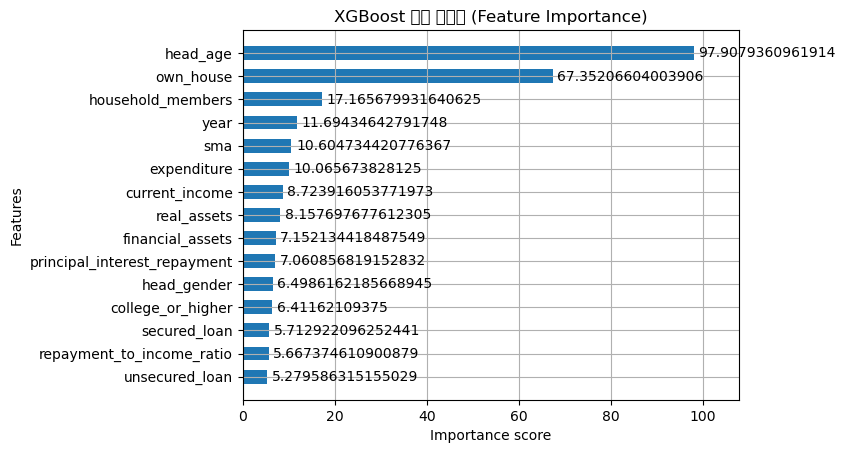

In [ ]:
# 8. 변수 중요도 (Feature Importance) 시각화
# 원 논문에서 "가구주 연령, 거주형태, 지출, 금융자산..." 순으로 영향을 미쳤다고 분석한 부분을 재현하는 코드입니다.
plt.figure(figsize=(10, 8))
plot_importance(xgb_model, max_num_features=15, importance_type='gain', height=0.6, title='XGBoost 변수 중요도 (Feature Importance)')
plt.show()

2. 변수 중요도 분석 (Feature Importance) 및 논문과의 비교
가장 주목해야 할 부분이다. 원 논문(주현태, 2023)의 결과와 조별 연구의 차별점이 드러난다.

- 기존 논문과의 일치성 (신뢰도 확보)
   - 뚜렷한 1, 2위 변수로 가구주 연령(head_age)과 자가 여부(own_house)가 도출

   - 이는 가구주 연령, 입주형태, 지출, 금융자산이 중요하게 작용했다는 원 논문의 분석 결과를 완벽하게 재현해 낸 것이다. 생애주기(연령)와 현재 주택 소유 여부가 여유자금의 투자처를 결정하는 핵심 요인임을 증명한다.

- 새로운 발견: 연도(year) 변수의 중요성
  - 변수 중요도 5위에 year (연도)가 위치
  
  - 원 논문은 저금리 시기(2019~2022년)만 다루었지만, 여러분의 조는 고금리/조정기(2023~2025년)를 통합. 모델이 year를 상위 요인으로 뽑았다는 것은, 금리 및 거시경제 환경이 변함에 따라 가계의 부동산 투자 결정 패턴이 유의미하게 달라졌음을 시사한다.

### SHAP 분석

원 논문 최신 분석 논문에서는 단순 Feature Importance뿐만 아니라, 어떤 변수가 투자 결정에 '긍정적(+)' 또는 '부정적(-)' 영향을 미쳤는지 설명하기 위해 SHAP(SHapley Additive exPlanations) 값을 자주 사용


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]



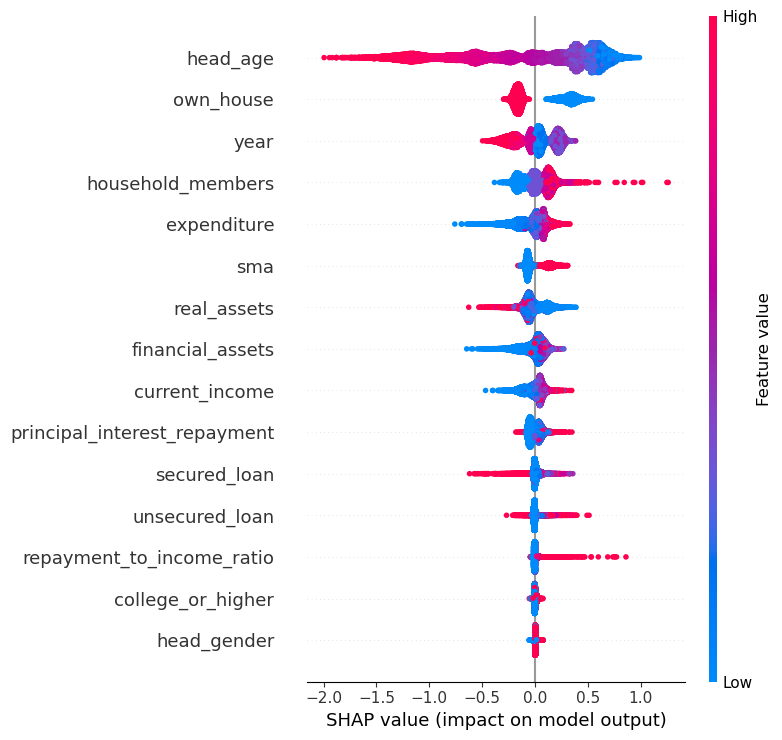

In [ ]:
!pip install shap
import shap

# SHAP 설명자 초기화 및 SHAP 값 계산
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# SHAP Summary Plot
# 변수별로 값이 높을 때(Red)와 낮을 때(Blue) 타겟에 미치는 영향을 시각화
shap.summary_plot(shap_values, X_test, plot_type="dot")

1. 기존 논문과 일치하는 결과 (연구의 신뢰도 확보)
- 가구주 연령 (head_age)
  - 해석: 파란색 점(낮은 연령)일수록 기준선(0)의 오른쪽(투자 확률 증가)에 분포하고, 빨간색 점(높은 연령)일수록 왼쪽(투자 확률 감소)에 분포한다.
  - 의미: 가구주 연령이 적을수록 투자 가능성이 높고, 연령이 높을수록 투자할 확률이 낮아진다는 기존 논문의 분석과 정확히 일치한다. 은퇴 시점 전후로 안전자산을 선호하게 되는 경향이 그대로 반영되었다.

- 지출 (expenditure) 및 가구원 수 (household_members)
  - 해석: 두 변수 모두 빨간색 점(값이 큼)이 주로 오른쪽(양의 방향)에 위치한다.
  - 의미: 지출이 많다는 것은 경제적 능력이 높음을 시사하며, 가구원 수가 많은 것 역시 상대적으로 여유 자금 투자에 긍정적인 성향을 보인다는 기존 연구 결과와 맥락을 같이 한다.

- 실물자산 (real_assets)

  - 해석: 실물자산이 많을수록(빨간색 점) 왼쪽(투자 의향 감소)으로 향하는 경향이 뚜렷하다.

  - 의미: 이미 일정 수준 이상의 실물자산(부동산 등)을 보유한 가구는 추가적인 부동산 투자보다는 포트폴리오 분산 등을 고려하여 투자 성향이 약해짐을 의미한다.

2. 차별점
- 연도 (year)의 뚜렷한 부정적 영향
  - 해석: 변수 값이 큰(최근 연도, 즉 2023~2025년) 빨간색 점들이 명확하게 기준선 왼쪽(투자 확률 감소)에 밀집해 있고, 파란색 점(과거 연도, 2019~2022년)은 오른쪽에 분포힌다.
  - 의미: 기존 논문의 저금리/상승기에는 영끌 등 부동산 투자가 활발했지만, 데이터에 새로 추가된 2023년 이후의 고금리 및 부동산 조정기에는 가계의 부동산 투자 심리가 급격히 얼어붙었음을 데이터가 완벽하게 입증하고 있다.  

- 자가 주택 거주 여부 (own_house)의 결과 반전
  - 해석: 빨간색 점(자가 보유=1)이 주로 기준선 왼쪽(음의 방향)에, 파란색 점(자가 미보유=0)이 오른쪽(양의 방향)에 분포하고 있다.
  - 의미: 원 논문에서는 자가 주택 거주가 부동산 투자에 긍정적인 영향을 준다고 분석했다. 하지만 이번 분석의 데이터에서는 유주택자의 투자 의향이 오히려 감소했다. 이는 고금리 기조가 이어지며 기존에 대출을 끼고 주택을 구입한 유주택자들이 이자 상환 부담 등으로 인해 추가적인 여유자금 투자 여력을 상실했거나 투자 심리가 위축되었음을 시사한다.